In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
# 定义数据集路径
data_dir = './data'

In [6]:
# 定义类别
categories = ['cats', 'dogs']

In [8]:
# 定义集合
sets = ['train', 'validation']

In [10]:
# 初始化统计字典
data_count = {set_name: {category: 0 for category in categories} for set_name in sets}

In [12]:
# 统计每个类别的图片数量
for set_name in sets:
    for category in categories:
        category_dir = os.path.join(data_dir, set_name, category)
        data_count[set_name][category] = len(os.listdir(category_dir))

In [14]:
# 检查并创建 Image 文件夹
if not os.path.exists('Image'):
    os.makedirs('Image')

In [16]:
# 绘制条形统计图并保存
def plot_bar(data_count):
    fig, ax = plt.subplots()
    index = range(len(sets))
    bar_width = 0.35

    for i, category in enumerate(categories):
        counts = [data_count[set_name][category] for set_name in sets]
        ax.bar([p + bar_width * i for p in index], counts, bar_width, label=category)

    ax.set_xlabel('数据集')
    ax.set_ylabel('图像数量')
    ax.set_title('训练集和验证集中每个类别的图像数量')
    ax.set_xticks([p + bar_width / 2 for p in index])
    ax.set_xticklabels(sets)
    ax.legend()

    # 保存图像到 Image 文件夹
    plt.savefig(os.path.join('Image', 'count.png'))
    plt.show()
    plt.close(fig)

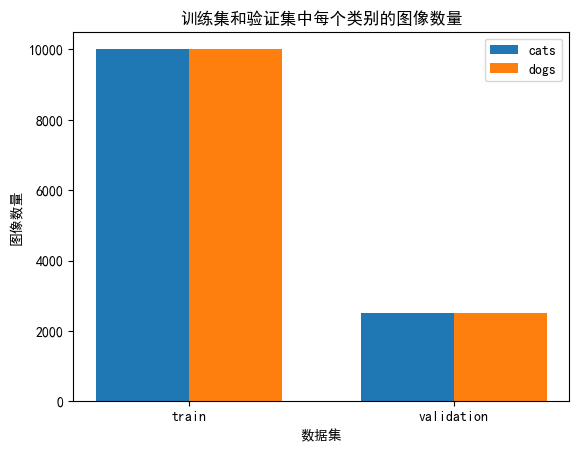

In [18]:
plot_bar(data_count)

In [20]:
# 绘制饼状比例图并保存
def plot_pie(data_count):
    for set_name in sets:
        counts = [data_count[set_name][category] for category in categories]
        plt.figure()
        plt.pie(counts, labels=categories, autopct='%1.1f%%')
        plt.title(f'各类别图像在 {set_name.capitalize()} 中的比例')

        # 保存图像到 Image 文件夹
        plt.savefig(os.path.join('Image', f'count_{set_name}.png'))
        plt.show()
        plt.close()

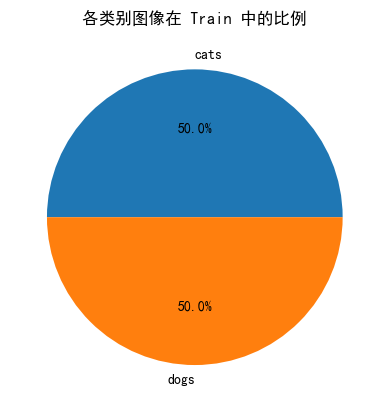

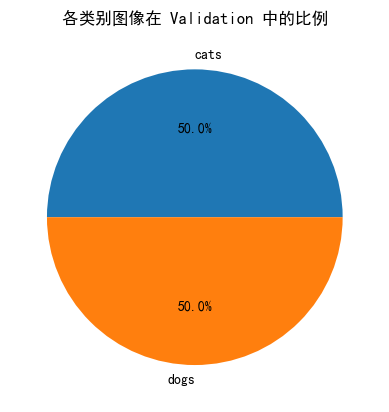

In [22]:
plot_pie(data_count)